# Task 3: Combining datasets to answer RQs


**Question:  How popular were the top most recent Kdramas around the world in the month of September 2026?**

## 1. Assembling Top 10 Shows with Highest Ratings

Goal: produce a list of article names.

First, I looked up the top shows with the highest ratings manually and assembled a list:

1. Teach you a lesson 9.0 
2. Four Hands, Two Sonatas 8.7
3. Bloodhounds Season 2 8.7
4. Agent Kim Reactivated 8.6
6. A Shop for Killers Season 2 8.5
7. The Wonderfools 8.5 
8. The legend of kitchen soldier 8.5
9. we are all trying here 8,5
10. A Bona Fide Killer 8.4
10. The East Palace 8.4

Next, we need a list of Wikipedia names. I also did this manually by looking at the unique URL of each title.

In [73]:
names = ['Teach_You_a_Lesson', 'Four_Hands,_Two_Sonatas', 'Bloodhounds_(TV_series)', 
         'Agent_Kim_Reactivated', 'The_East_Palace', 'A_Shop_for_Killers',
         'The_Wonderfools', 'The_Legend_of_Kitchen_Soldier','We_Are_All_Trying_Here',
         'A_Bona_Fide_Killer']

## 2. Retrieve Wiki Daily Pageviews (one day first)

The idea is to get the pageviews tsv of each day in September. For each day, search the df with the query (10 in total, 1 for each drama).

Let's just start with the example from the Wednesday notebook.

In [63]:
import pandas as pd
import requests, io

url = "https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-29.tsv"

headers = {'User-Agent': 'MyDataAnalysisScript/1.0 (contact: wendywellesley@gmail.com)'}
response = requests.get(url, headers=headers)


In [ ]:
df = pd.read_csv(io.StringIO(response.text), sep='\t', header=None)
df.head()

,0,1,2,3,4,5,6
0,Algeria,DZ,ar.wikipedia,3947,Ø°ÙØ§Ø¡_Ø§ØµØ·ÙØ§Ø¹Ù,Q11660,122
1,Argentina,AR,es.wikipedia,3094323,Juana_Viale,Q9016209,115
2,Argentina,AR,es.wikipedia,327209,JosÃ©_Mourinho,Q79983,114
3,Argentina,AR,es.wikipedia,4449701,Copa_Libertadores,Q184795,386
4,Argentina,AR,es.wikipedia,47340,Thomas_Sankara,Q202155,119


Let's rename these columns.

In [68]:
columns = ['country', 'country-code', 'wiki', 'page_id', 'article', 'qid', 'views']
df.columns = columns

In [69]:
df.head()

,country,country-code,wiki,page_id,article,qid,views
0,Algeria,DZ,ar.wikipedia,3947,Ø°ÙØ§Ø¡_Ø§ØµØ·ÙØ§Ø¹Ù,Q11660,122
1,Argentina,AR,es.wikipedia,3094323,Juana_Viale,Q9016209,115
2,Argentina,AR,es.wikipedia,327209,JosÃ©_Mourinho,Q79983,114
3,Argentina,AR,es.wikipedia,4449701,Copa_Libertadores,Q184795,386
4,Argentina,AR,es.wikipedia,47340,Thomas_Sankara,Q202155,119


In [70]:
df.shape

(293466, 7)

Try to filter this df for specific queries:

In [71]:
query = names[0]

filtered_df = df[
    df['article'].str.contains(query, case=False, na=False)
]

filtered_df.head()

,country,country-code,wiki,page_id,article,qid,views
5054,Singapore,SG,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,111
8713,United States,US,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,369
38494,India,IN,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,244
75513,Indonesia,ID,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,129
87615,Philippines,PH,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,139


In [72]:
filtered_df.shape

(5, 7)

This means that on this day, only five countries looked this kdrama up on Wikipedia, and each country had a certain number of views.

## 3. Set up loop for URL updates to capture entire September

This is a simple but important step! We will automate the collection of all tsvs in September by making the URL a f-string.

In [14]:
sept_urls = []
for i in range(1,31):  # 30 days in september
    if i < 10:
        date = f"2026-09-0{i}"
    else:
        date = f"2026-09-{i}"
    url = f"https://analytics.wikimedia.org/published/datasets/country_project_page/{date}.tsv"
    sept_urls.append(url)

In [15]:
sept_urls[:5]

['https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-01.tsv',
 'https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-02.tsv',
 'https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-03.tsv',
 'https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-04.tsv',
 'https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-05.tsv']

## 4. 

Goal: columns = date, country, article, pageviews; each row is one country one article.

Pseudocode for the full block of code:

create: kdrama_df    
for every url:    
-> for every query:   
--> create a column for date that is just the date  
--> merge the smaller filtered_df with the larger kdrama_df

***GENAI USE***.    Upon testing out plotting by show name, I realized there was an error with the parsing, so I debugged with GenAI. I went back to this code to update it with the csv.QUOTE_NONE parameter to address the UserWarning!  

In [91]:
"""
Code for debugging:

for query in names:
    matches = full_df.loc[
        full_df["article"].str.contains(
            query, case=False, regex=False, na=False
        ),
        "article"
    ].drop_duplicates()

    print(f"\n{query!r} matched:")
    print([repr(title) for title in matches])



Archive
columns = ['country', 'country-code', 'wiki', 'page_id', 'article', 'qid', 'views']
full_df = pd.DataFrame()

for i in range(0, len(sept_urls)): # stops befre 31 --> 30
    date = f"2026-09-{i}"
    url = sept_urls[i]

    # get the daily tsv first
    headers = {'User-Agent': 'MyDataAnalysisScript/1.0 (contact: wendywellesley@gmail.com)'}
    response = requests.get(url, headers=headers)

    # read in as df
    day_df = pd.read_csv(io.StringIO(response.text), sep='\t', header=None)
    day_df.columns = columns

    # add a column for date
    day_df['date'] = date

    for j in range(1, len(names)): # each kdrama
        query = names[j]
        filtered_df = day_df[
            day_df['article'].str.contains(query,case=False, na=False)]
        full_df = pd.concat([full_df, filtered_df], axis=0, ignore_index = True)
"""


In [ ]:
import csv # GENAI

columns = ['country', 'country-code', 'wiki', 'page_id', 'article', 'qid', 'views']
full_df = pd.DataFrame()

for i in range(0, len(sept_urls)): # stops befre 31 --> 30
    date = f"2026-09-{i}"
    url = sept_urls[i]

    # get the daily tsv first
    headers = {'User-Agent': 'MyDataAnalysisScript/1.0 (contact: wendywellesley@gmail.com)'}
    response = requests.get(url, headers=headers)

    # read in as df
    day_df = pd.read_csv(
    io.BytesIO(response.content),
    sep="\t",
    header=None,
    encoding="utf-8",
    quoting=csv.QUOTE_NONE #GENAI 
)
    day_df.columns = columns

    # add a column for date
    day_df['date'] = date

    for j in range(0, len(names)): # each kdrama
        query = names[j]
        filtered_df = day_df.loc[day_df["article"].eq(query)] # GENAI
        full_df = pd.concat([full_df, filtered_df], axis=0, ignore_index = True)

In [92]:
full_df.shape

(1523, 8)

In [94]:
full_df.tail()

,country,country-code,wiki,page_id,article,qid,views,date
1518,India,IN,en.wikipedia,78258360,The_Wonderfools,Q130748503,114,2026-09-29
1519,United States,US,en.wikipedia,78258360,The_Wonderfools,Q130748503,232,2026-09-29
1520,Philippines,PH,en.wikipedia,83488921,A_Bona_Fide_Killer,Q139411314,131,2026-09-29
1521,India,IN,en.wikipedia,83488921,A_Bona_Fide_Killer,Q139411314,94,2026-09-29
1522,United States,US,en.wikipedia,83488921,A_Bona_Fide_Killer,Q139411314,250,2026-09-29


In [90]:
full_df['article'].unique()

array(['Teach_You_a_Lesson', 'Four_Hands,_Two_Sonatas',
       'Bloodhounds_(TV_series)', 'Agent_Kim_Reactivated',
       'The_East_Palace', 'A_Shop_for_Killers', 'The_Wonderfools',
       'The_Legend_of_Kitchen_Soldier', 'We_Are_All_Trying_Here',
       'A_Bona_Fide_Killer'], dtype=object)

## 5. Plotting - Views Sorted by Country

We can approach this by grouping the rows by their country and summing up the column of views. This should give us a series.

In [95]:
by_country = full_df.groupby('country')['views'].sum().sort_values(ascending=False)
by_country

country
United States     98204
India             58811
Indonesia         39943
Philippines       37576
Singapore         23620
Malaysia          21231
Canada            12349
United Kingdom    10690
Japan             10219
Australia          8657
France             6293
Germany            6190
Brazil             3909
Italy              3086
Thailand           1288
Nigeria             950
Romania             334
Poland              289
Name: views, dtype: int64

On a separate note, through trial and error, I learned that you do NOT Need to pass arguments into sort_values when we are dealing wiht a series because there is only one column.

In [96]:
by_country.shape

(18,)

We have 18 countries.

We will use matplotlib to plot.

<BarContainer object of 18 artists>

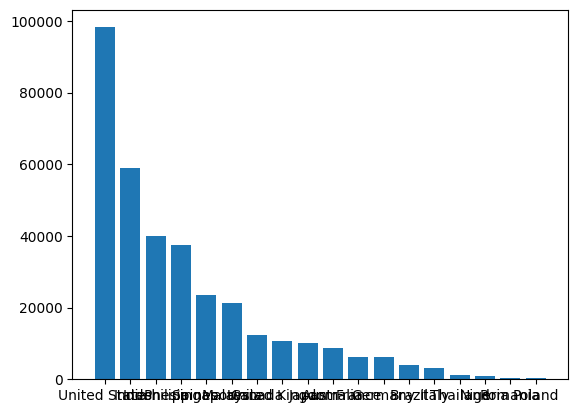

In [97]:
import matplotlib.pyplot as plt

plt.bar(by_country.index, by_country.values)

This display is awful!

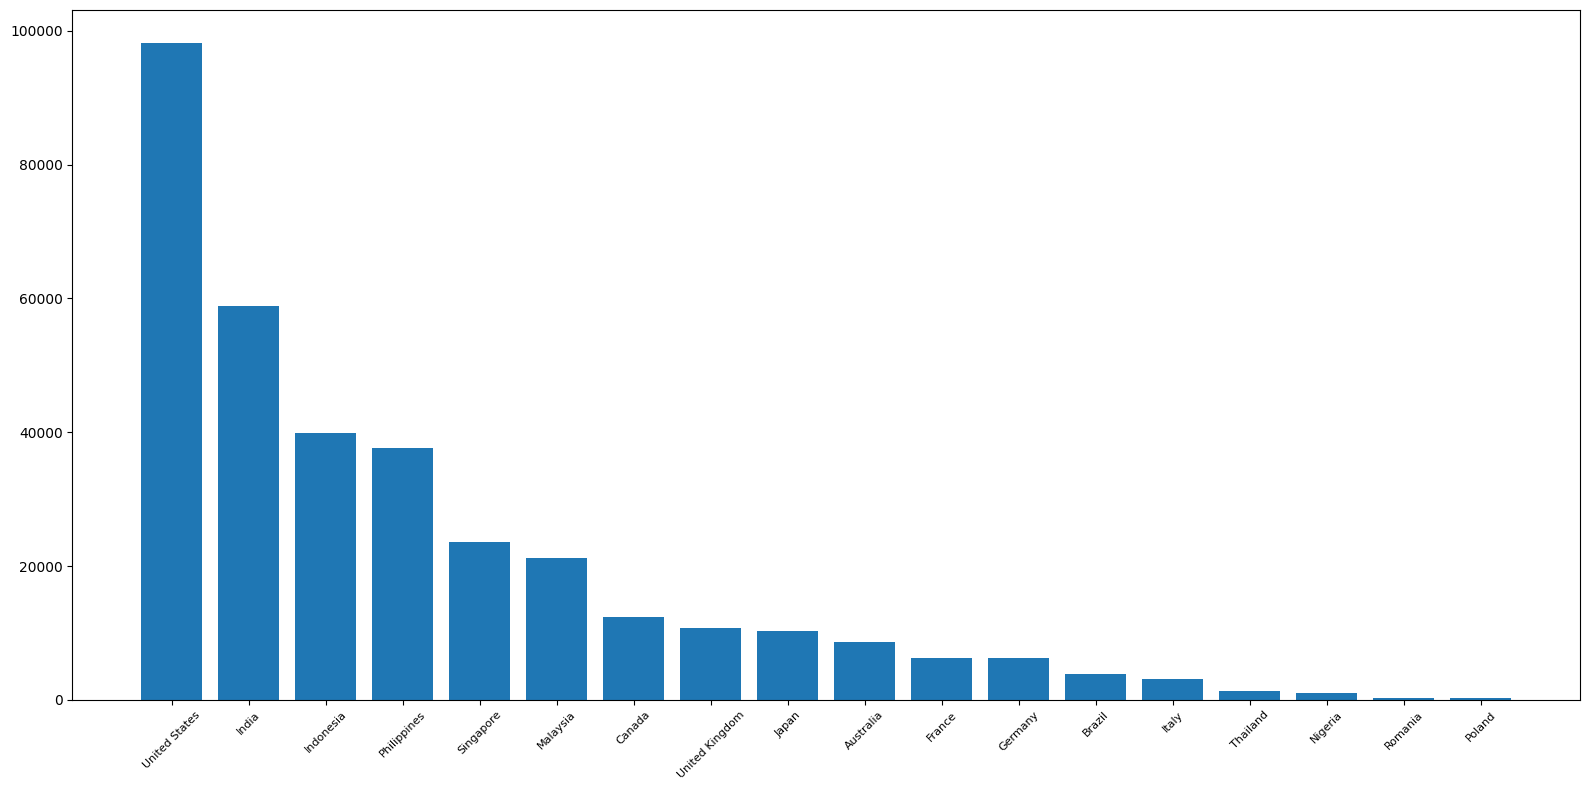

In [98]:
fig, ax = plt.subplots(figsize=(16, 8)) #make sure the plot is long enough
ax.bar(by_country.index, by_country.values)
ax.tick_params(axis="x", labelsize=8, labelrotation=45) #make the text font smaller and rotate them so they can all fit
fig.tight_layout()

We can see that the US leads by far followed by India and Indonesia. 

## 6. Plotting - Views Sorted by Show

In [104]:
by_show = full_df.groupby('article')['views'].sum().sort_values(ascending=True)
by_show

article
We_Are_All_Trying_Here             2492
The_Legend_of_Kitchen_Soldier      3870
Bloodhounds_(TV_series)            8183
The_East_Palace                   12167
The_Wonderfools                   13836
A_Shop_for_Killers                18133
Teach_You_a_Lesson                47148
Agent_Kim_Reactivated             54615
A_Bona_Fide_Killer                70404
Four_Hands,_Two_Sonatas          112791
Name: views, dtype: int64

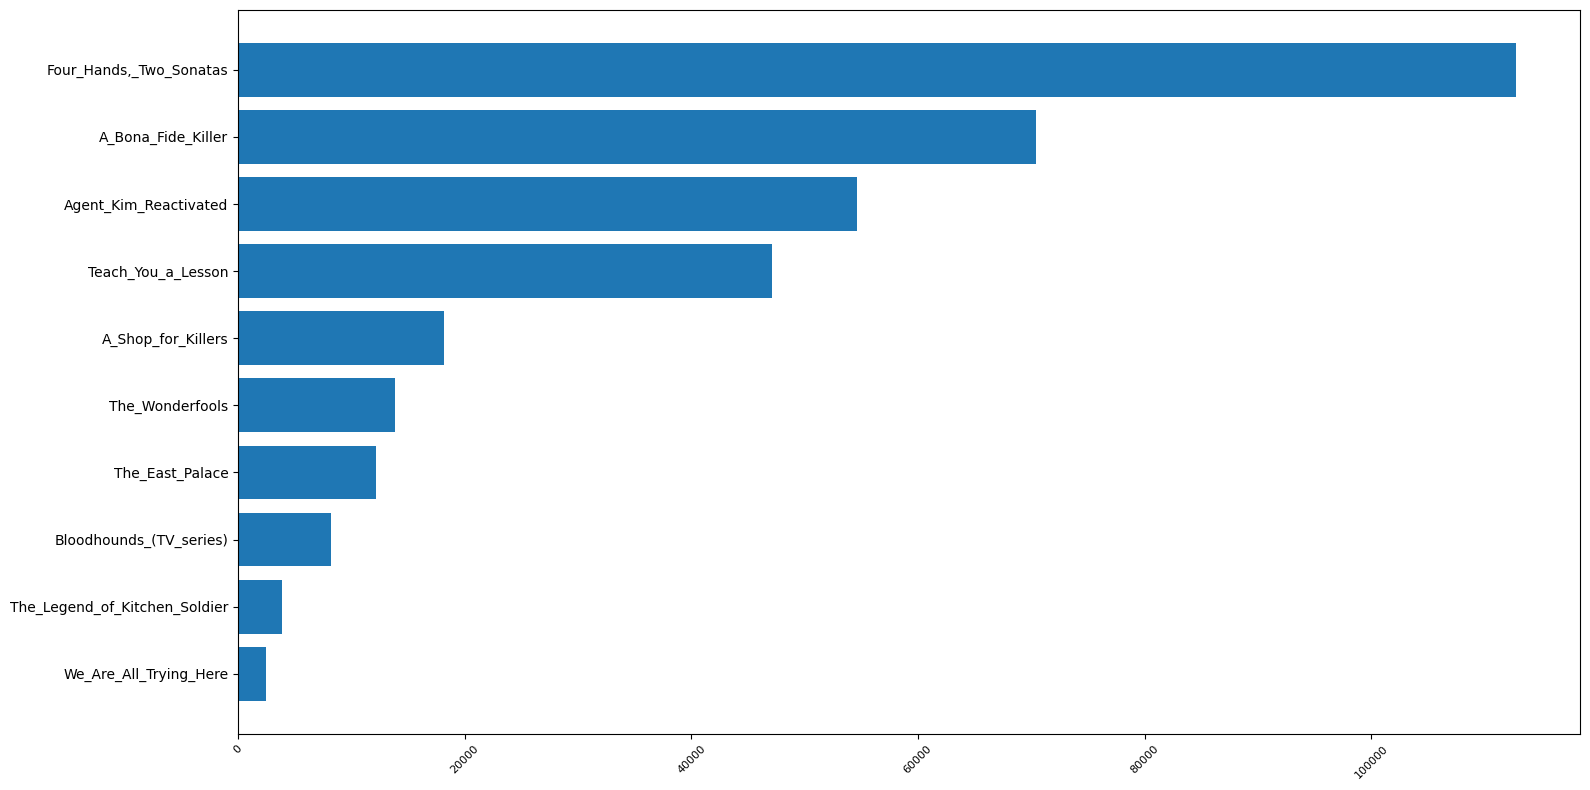

In [105]:
fig, ax = plt.subplots(figsize=(16, 8)) #make sure the plot is long enough
ax.barh(by_show.index, by_show.values)
ax.tick_params(axis="x", labelsize=8, labelrotation=45) #make the text font smaller and rotate them so they can all fit
fig.tight_layout()

## 7. Qualitative Answer

**Does the popularity in Wikipedia pageviews correlate to the rating for the shows in MyDramaList? (This is an eyeballing question at the moment, but in the future can become quantitative by combining the two data sources.)**

The most highly rated show, Teach You a Lesson rated at 9.0, is only at number 4 on the popularity by pageviews. On the other hand, Four Hands, Two Sonatas is by far the most popular but only has an 8.7 rating. Additionally, A Bona Fide Killer is only rated at 8.4 but is second in popularity. Therefore, it might be the case that the most popular is not most highly rated but most highly rated tends to have a higher rating.